<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_5_bayes.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Bayes Law and the Beta-Binomial model

In this assignment, you will learn more intuition for priors, posteriors, and the role that data plays in our inferences about a latent hypothesis.

---

## Learning Goals
- Understand priors and posteriors
- Understand the beta-binomial model
- Understand how data eventually overwhelms the prior


## 1. Exploring the beta prior

The beta distribution is a continuous distribution over the interval [0,1].  Because this is exactly the domain of a single probability (such as the probability that a coin will come up heads), it can be used as a prior distribution over an unknown parameter.  To start, let's plot it for various values of its two parameters, which we will call (a) and (b).

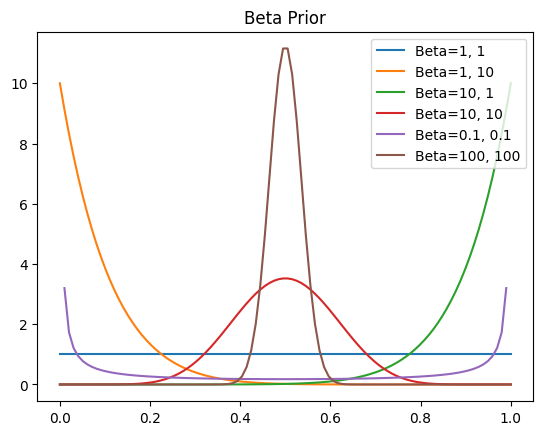

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import beta

# Test various values of alpha and beta
parameter_values = [
    (1, 1),
    (1, 10),
    (10, 1),
    (10, 10),
    (0.1, 0.1),
    (100,100)
]

xvals = np.linspace(0, 1, 100)

# Plot the beta prior for each value of beta
for a, b in parameter_values:
    yvals = beta.pdf( xvals, a, b )
    plt.plot(xvals, yvals, label=f"Beta={a}, {b}" )

plt.legend()
plt.title("Beta Prior")
plt.show()


### Reflection
- Consider the beta distribution defined by each setting of the parameters (a) and (b). Which is the most uniform? Which is the most confident? Which is binary?

The most uniform beta distribution is found via $\text{Beta}(1, 1)$, which makes sense because this is mathematically equivalent to $\text{Uniform}(0, 1)$.  Therefore, it is guaranteed to be the "most" uniform, since it is entirely uniform by construction.

The most confident beta distribution is given by $\text{Beta}(100, 100)$.  I say this because it both has the narrowest band of (essentially) non-zero values and also has the smallest calculated variance of all the priors considered.  In more probabilistic terms, because $a = b$, the resulting distribution is a symmetric bell-curve with extremely small variance ($\sigma^2 \approx 0.00124$), which is the smallest variance of the distributions plotted, confirming it is the distribution with the greatest confidence.

While no beta distribution is ever truly binary, $\text{Beta}(0.1, 0.1)$ is the closest to a binary distribution since it has relatively large tails near $0$ and $1$.  This U-shape with much greater density near the endpoints 0 and 1 than in the interior approximates a binary distribution far more than any other distribution casdfasdfasdfasdfsadfsadgasdgfffffff


## 2. Calculating the posterior

Given a prior defined by parameters (a) and (b), and some data, we'd now like to calculate (and visualize) the posterior distribution.


### Exercise 2

Suppose we have a coin that is weighted, but we don't know the weight. Call the unknown weight $\theta$.

Suppose now we flip the coin 10 times, and we see "HHTTHTHHHH".

Your task is to visualize how that data would affect our belief about $\theta$, given an initial belief about $\theta$.

To do this, you must do the following:

- For each of the prior parameter values in the list of parameter values from Part 1, calculate the posterior distribution $p(\theta|data)$
- Create a new figure for each setting of the prior parameter values.
- Plot the prior distribution, and the corresponding posterior, on the same figure.  (When you're done, you should have six figures, each with two plots)

In [3]:
num_heads = 7
num_tails = 3

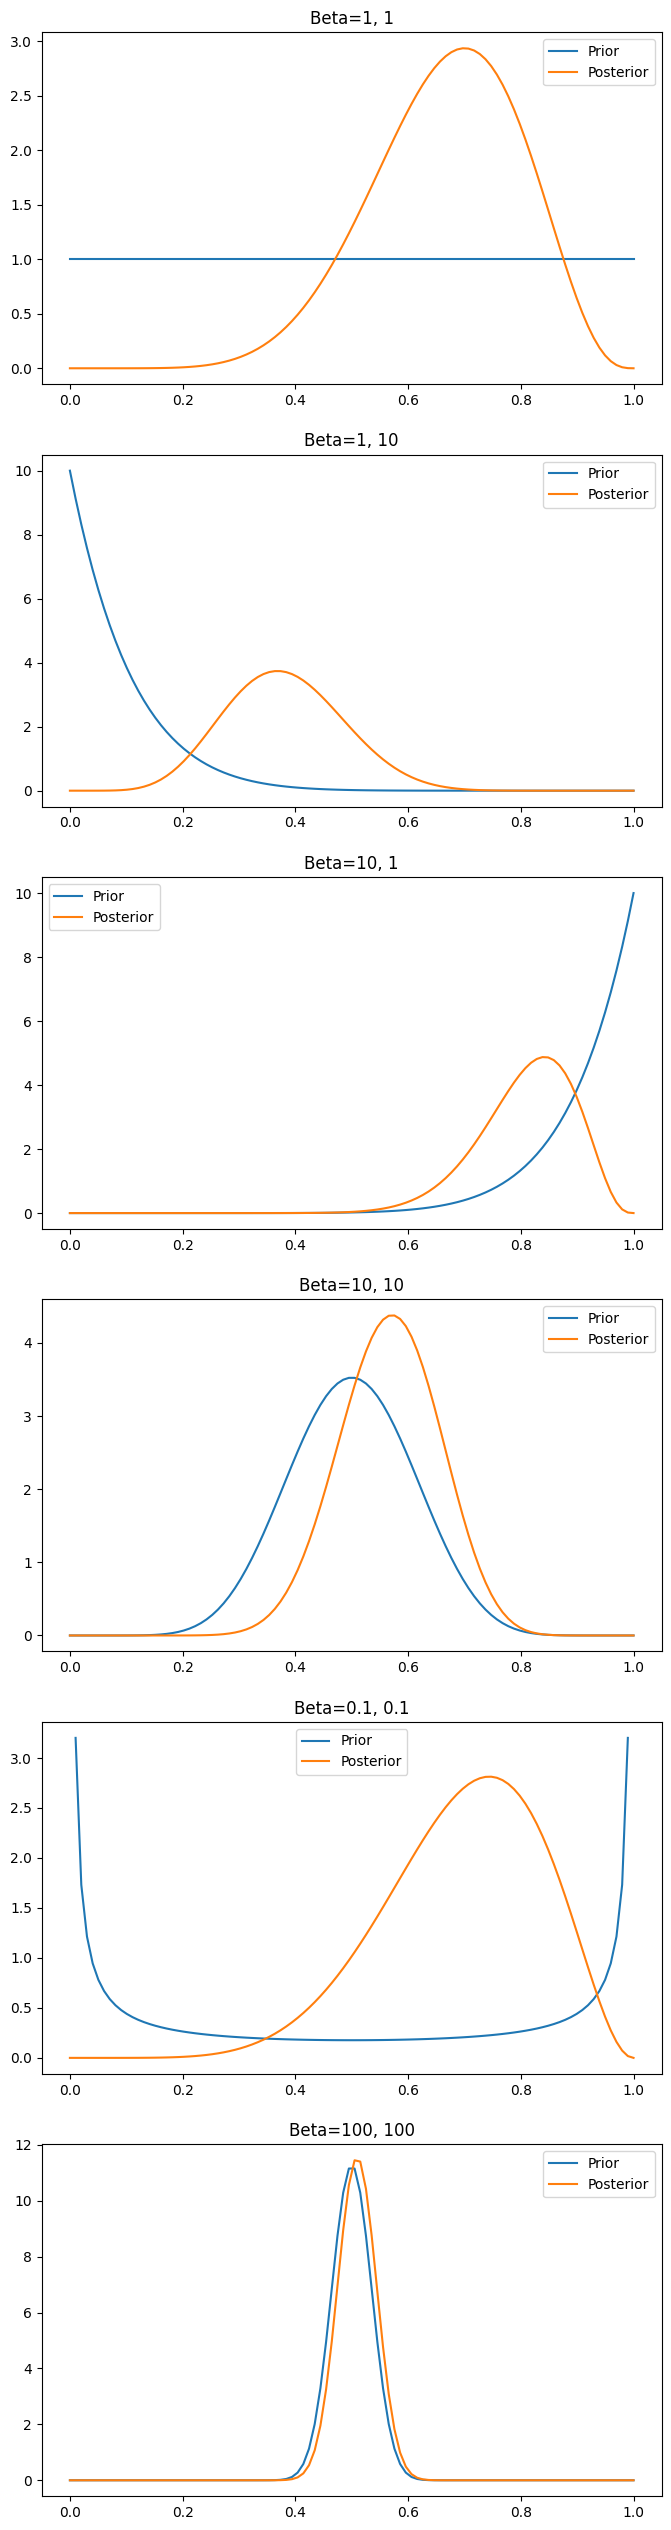

In [10]:
plt.figure(figsize=(8, 32))

# Plot the beta prior for each value of beta
plt_index = 0

for a, b in parameter_values:
    plt_index += 1
    plt.subplot( 6, 1, plt_index )
    plt.title( f"Beta={a}, {b}" )

    # this is the prior, as calculated in part 1
    yvals = beta.pdf( xvals, a, b )
    plt.plot(xvals, yvals, label=f"Prior")

    # now calculate the posterior, and plot it
    # XXX your code here
    # Note that is via the conjugate prior of the Beta distribution.
    yvals = beta.pdf( xvals, a + num_heads, b + num_tails)
    plt.plot(xvals, yvals, label=f"Posterior")
    plt.legend()


plt.show()


## 3. Reflection

### Exercise 3
Answer in 2–3 sentences each:

1. Which prior was the "strongest" (ie, changed the least in response to seeing new data)? Which was the "weakest"?
2. Suppose you wanted to create a prior that was very confident about the value of $\theta$. How would you do that?
3. What would an "infinitely strong" prior look like?


1. The prior $\text{Beta}(100, 100)$ what the strongest (i.e., it changed the least in response to seeing new data) -- precisely for the same reason it was the most confident prior (see my response to `Exercise 1`).  While it's difficult to determine by visual inspection which prior was the weakest, the prior $\text{Beta}(0.1, 0.1)$ theoretically will change the most as it is the weakest initial concentration (i.e., we can think of $a + b$ being the initial observations, so $\text{Beta}(0.1, 0.1)$ has an initial concentration of just $0.1 + 0.1 = 0.2 << 10$).  Thus, because $\text{Beta}(0.1, 0.1)$ was the smallest $a + b$ concentration, it was the weakest concentration.

2. To create a prior that was very confident about the value of $\theta$, I would create a prior distribution with as minimal variance as possible, while further ensuring the center (expected value) of the distribution is $\theta$ (i.e., $\frac{a}{a+b} = \theta$).  That is, I would concentrate the prior around a single value as much as possible around $\theta$ in order to express as much confidence as possible in the value $\theta$.

3. To be mathematically precise, an "infinitely strong" prior would look like a degenerate distribution (i.e., a Dirac point mass, $\delta_\theta$) with zero variance an inability to respond to an update of any finite data.  In other words, it would look like an infinitely tall, infinitely thin band along the single value of $\theta$.